In [261]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

In [262]:
sx = qt.sigmax()
sz = qt.sigmaz()

ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

def coef_alpha_lz(t):
    return 0.5 - t

def coef_alpha_lsz(t, args):
    tw = args['t_wait']
    if (t < 0.5):
        coeff =  0.5 - t
    elif (t > tw + 0.5):
        coeff = 0.5 - (t-tw)
    else:
        coeff = 0
    return coeff


def H_qutip_LZ(epsilon, alpha):
    H_epsilon = 0.5*epsilon*sx
    H_alpha = alpha*sz

    H = [H_epsilon, [H_alpha, coef_alpha_lz]]

    return H

def H_qutip_LSZ(epsilon, alpha):
    H_epsilon = 0.5*epsilon*sx
    H_alpha = alpha*sz

    H = [H_epsilon, [H_alpha, coef_alpha_lsz]]

    return H

def H_numpy_lz(a, e, t):
    sz = np.array([[1,0],[0,-1]])
    sx = np.array([[0,1],[1,0]])
    Hx = a*sx + e*sz
    Hz = e*sz
    H = t*Hz + (0.5 - t)*Hx
    return H

def H_numpy_lsz(a, e, t, tw):
    sz = np.array([[1,0],[0,-1]])
    sx = np.array([[0,1],[1,0]])
    args = {'t_wait':tw}
    a = a*coef_alpha_lsz(t, args)
    Hx = a*sx
    Hz = 0.5*e*sz
    H = Hz + Hx
    return H

In [263]:
def H_numpy_lz(a, e, t):
    # Correct Pauli matrices
    sigma_x = np.array([[0, 1], [1, 0]])
    sigma_z = np.array([[1, 0], [0, -1]])
    
    H = 0.5*e*sigma_x + a*(0.5 - t)*sigma_z
    return H

def H_numpy_lsz(a, e, t, tw):
    # Correct Pauli matrices
    sigma_x = np.array([[0, 1], [1, 0]])
    sigma_z = np.array([[1, 0], [0, -1]])
    
    # Match the QuTiP structure
    coeff = coef_alpha_lsz(t, {'t_wait': tw})
    H = 0.5*e*sigma_x + a*coeff*sigma_z
    return H

def H_qutip_LSZ(epsilon, alpha):
    # This matches H_numpy_lsz_corrected structure
    H_epsilon = 0.5*epsilon*qt.sigmax()
    H_alpha = alpha*qt.sigmaz()
    H = [H_epsilon, [H_alpha, coef_alpha_lsz]]
    return H

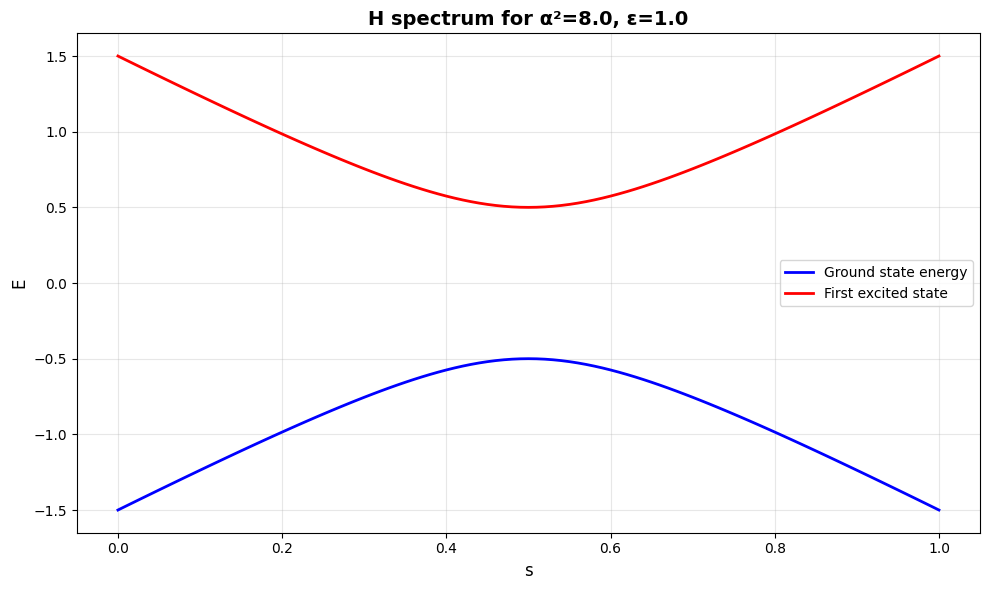

In [264]:
alpha = np.sqrt(8)
epsilon = 1
t_list = np.linspace(0, 1, 101)
g, e = [], []

for t in t_list:
    Ham = H_numpy_lz(alpha, epsilon, t)
    eigvals, eigvecs = np.linalg.eigh(Ham)
    g.append(eigvals[0])
    e.append(eigvals[1])

# Create plot
plt.figure(figsize=(10, 6))

# Plot each line
plt.plot(t_list, g, label='Ground state energy', linewidth=2, color='blue', linestyle='-')
plt.plot(t_list, e, label='First excited state', linewidth=2, color='red', linestyle='-')

# Customize
plt.title(f'H spectrum for α²={alpha**2:.1f}, ε={epsilon:.1f}', fontsize=14, fontweight='bold')
plt.xlabel('s', fontsize=12)
plt.ylabel('E', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Show
plt.tight_layout()
plt.show()

In [265]:
epsilon = 1
alpha_list = np.linspace(0, 10, 101)
ti = 0
tf = 1
nsteps = 1001
times = np.linspace(ti, tf, nsteps)

pc, pe = [], []

for alpha in alpha_list:

    H_i = H_numpy_lz(alpha, epsilon, 0)
    eigvals_i, eigvecs_i = np.linalg.eigh(H_i)

    H_f = H_numpy_lz(alpha, epsilon, 1)
    eigvals_f, eigvecs_f = np.linalg.eigh(H_f)

    psi0 = eigvecs_i[0][0]*ket0 + eigvecs_i[0][1]*ket1

    H = H_qutip_LZ(epsilon, alpha)

    result = qt.sesolve(H, psi0, times)

    final_state = result.states[-1]

    dot_c = np.dot(final_state.full().flatten(), eigvecs_f[0])
    dot_e = np.dot(final_state.full().flatten(), eigvecs_f[1])
    pc.append(dot_c*dot_c.conj())
    pe.append(dot_e*dot_e.conj())

/Users/omichel/.pyenv/versions/spectroscopy/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/omichel/.pyenv/versions/spectroscopy/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


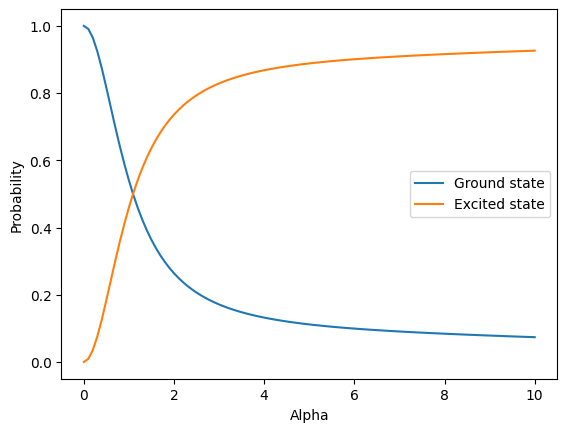

In [266]:
#print((np.log(pe)[-1] - np.log(pe)[0]) / ((1/alpha_list)[-1] - (1/alpha_list)[0]))
plt.plot(alpha_list, pc, label="Ground state")
plt.plot(alpha_list, pe, label="Excited state")
plt.xlabel('Alpha')
plt.ylabel('Probability')
plt.legend()

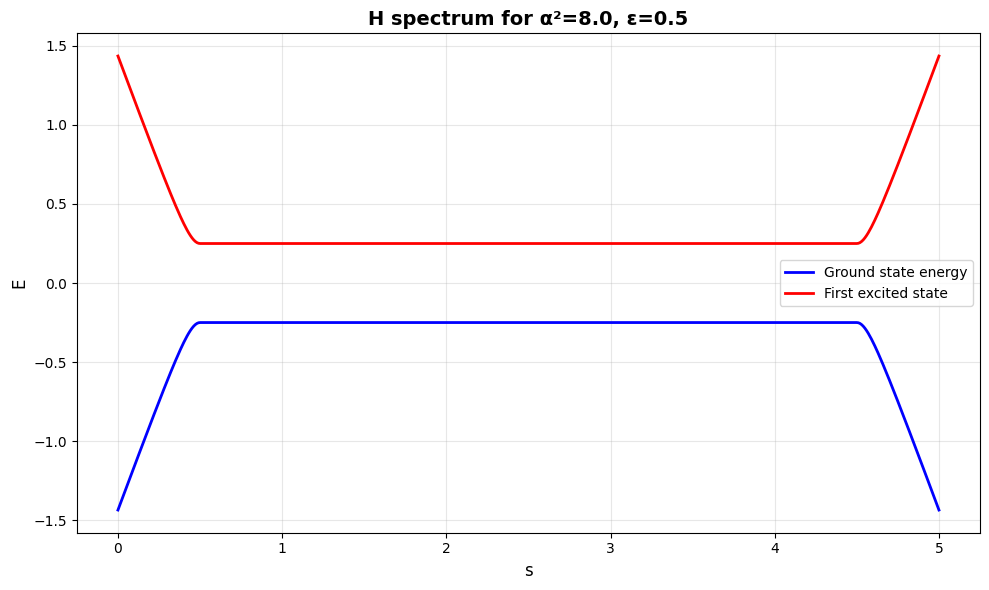

In [321]:
alpha = np.sqrt(8)
epsilon = 0.5
ti = 0
tf = 1
t_wait = 4
dt = 1e-2

nsteps = int((tf+t_wait)/dt)
t_list = np.linspace(ti, tf+t_wait, nsteps)

g, e = [], []

for t in t_list:
    Ham = H_numpy_lsz(alpha, epsilon, t, t_wait)
    eigvals, eigvecs = np.linalg.eigh(Ham)
    g.append(eigvals[0])
    e.append(eigvals[1])

# Create plot
plt.figure(figsize=(10, 6))

# Plot each line
plt.plot(t_list, g, label='Ground state energy', linewidth=2, color='blue', linestyle='-')
plt.plot(t_list, e, label='First excited state', linewidth=2, color='red', linestyle='-')

# Customize
plt.title(f'H spectrum for α²={alpha**2:.1f}, ε={epsilon:.1f}', fontsize=14, fontweight='bold')
plt.xlabel('s', fontsize=12)
plt.ylabel('E', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Show
plt.tight_layout()
plt.show()

In [322]:
epsilon = 2.34
alpha = np.sqrt(8)
ti = 0
tf = 1
t_wait_list = np.linspace(0, 10, 101)
dt = 1e-3

pc, pe = [], []

H_i = H_numpy_lz(alpha, epsilon, 0)
eigvals_i, eigvecs_i = np.linalg.eigh(H_i)

H_f = H_numpy_lz(alpha, epsilon, 1)
eigvals_f, eigvecs_f = np.linalg.eigh(H_f)

psi0 = eigvecs_i[0][0]*ket0 + eigvecs_i[0][1]*ket1

for tw in t_wait_list:

    nsteps = int((tf+tw)/dt)

    times = np.linspace(ti, tf+tw, nsteps)

    H = H_qutip_LSZ(epsilon, alpha)

    result = qt.sesolve(H, psi0, times, args={'t_wait': tw})

    final_state = result.states[-1]

    dot_c = np.dot(final_state.full().flatten(), eigvecs_f[0])
    dot_e = np.dot(final_state.full().flatten(), eigvecs_f[1])
    pc.append(dot_c*dot_c.conj())
    pe.append(dot_e*dot_e.conj())

In [323]:
def simplest_fourier_analysis(pc, t_wait_list):
    """
    Absolute simplest Fourier analysis - just 2 plots
    """
    y = np.array(pc)
    t = np.array(t_wait_list)
    
    # Basic calculations
    N = len(y)
    dt = t[1] - t[0]
    
    # FFT
    spectrum = np.fft.fft(y)
    freqs = np.fft.fftfreq(N, dt)
    magnitude = np.abs(spectrum)
    
    # Find peak frequency (excluding DC component at f=0)
    positive_idx = np.where(freqs > 0)[0]
    # Exclude the first positive frequency if it's very close to 0
    # or start from a minimum threshold
    min_freq_threshold = 0.01 * np.max(freqs[positive_idx])  # adjustable threshold
    valid_idx = positive_idx[freqs[positive_idx] > min_freq_threshold]
    
    peak_idx = valid_idx[np.argmax(magnitude[valid_idx])]
    dominant_freq = freqs[peak_idx]
    amplitude = 2 * magnitude[peak_idx] / N
    
    # Create figure
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Original signal
    plt.subplot(1, 2, 1)
    plt.plot(t, y, 'b-', linewidth=2)
    plt.xlabel('Time')
    plt.ylabel('Signal')
    plt.title(f'Original Signal\nFrequency ≈ {dominant_freq:.3f}')
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Fourier spectrum (excluding DC or starting from small freq)
    plt.subplot(1, 2, 2)
    # Option 1: Plot from index 1 to skip DC
    plt.plot(freqs[1:N//2], magnitude[1:N//2], 'r-', linewidth=2)
    plt.axvline(dominant_freq, color='k', linestyle='--', 
                label=f'Peak: f={dominant_freq:.3f}\nA={amplitude:.3f}')
    plt.xlabel('Frequency')
    plt.ylabel('Magnitude')
    plt.title('Fourier Transform (DC removed)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Peak frequency: {dominant_freq:.6f}")
    print(f"Amplitude: {amplitude:.6f}")
    
    return dominant_freq, amplitude

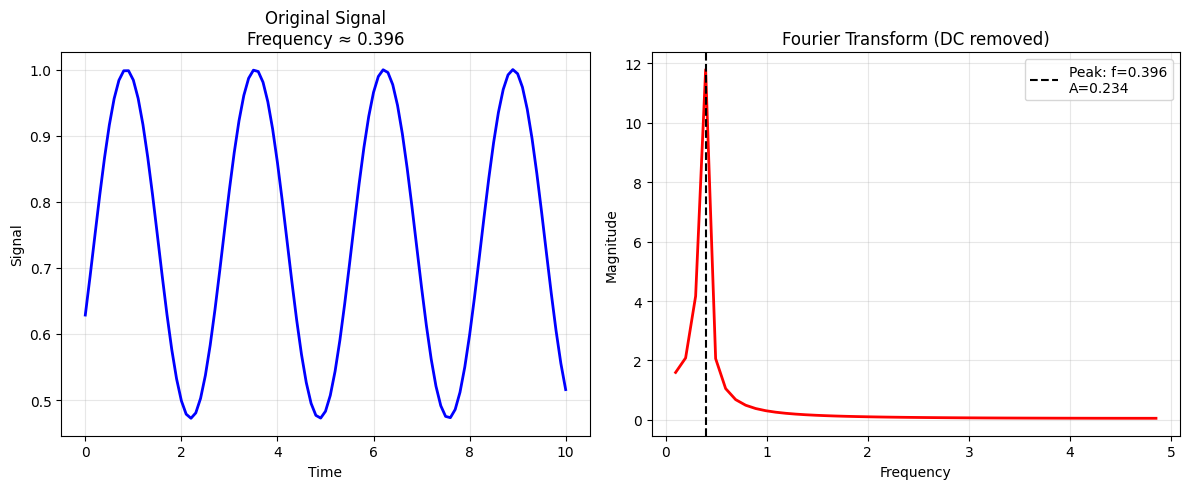

Peak frequency: 0.396040
Amplitude: 0.233563


In [324]:
dominant_freq, amplitude = simplest_fourier_analysis(pc, t_wait_list)

In [325]:
print("Period:", 1/dominant_freq)
epsilon_rec = 2*np.pi*dominant_freq
print('recovered epsilon:', epsilon_rec)

Period: 2.5250000000000004
recovered epsilon: 2.4883902206651825
